<h1 style='text-align: center;'>Random Forest</h1>

<h2>Import Libraries</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

<h2>Load Data</h2>

In [2]:
df = pd.read_csv('clean_data/clean_wthr_dt.csv')
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").reset_index(drop=True)

df.head(5)

,ds,HourlyAltimeterSetting,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyRelativeHumidity,HourlySeaLevelPressure,HourlyStationPressure,HourlyVisibility,HourlyWetBulbTemperature,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,SOURCE,REPORT_TYPE
0,2024-01-01 00:00:00,239.955918,28.898257,41.982568,0.069097,59.83137,238.854888,231.777947,10.794917,36.739289,68.31805,5.352951,2024.0,1.0,1.0,0.0,7.0,FM-15
1,2024-01-01 01:00:00,239.895918,32.000000,42.000000,0.069097,68.00000,30.030000,29.565000,9.970000,38.000000,230.00000,5.000000,2024.0,1.0,1.0,1.0,7.0,FM-15
2,2024-01-01 02:00:00,30.020000,31.000000,41.000000,0.000000,67.00000,30.020000,29.550000,10.000000,37.000000,230.00000,3.000000,2024.0,1.0,1.0,2.0,7.0,FM-15
3,2024-01-01 03:00:00,30.030000,30.000000,40.000000,0.000000,68.00000,30.020000,29.560000,10.000000,36.000000,240.00000,5.000000,2024.0,1.0,1.0,3.0,7.0,FM-15
4,2024-01-01 04:00:00,239.885918,30.000000,38.000000,0.069097,73.00000,30.010000,29.545000,9.970000,35.000000,240.00000,5.000000,2024.0,1.0,1.0,4.0,7.0,FM-15


<h2>Filter Data</h2>

In [3]:
# Forecasting Dates (Needs to be hidden from model)
f_start = pd.Timestamp("2025-09-17 00:00:00")
f_end = pd.Timestamp("2025-09-30 23:59:59")

# Filter
mask = (df["ds"] >= f_start) & (df["ds"] <= f_end)
df = df.loc[~mask].copy()
df['ds'].max()

Timestamp('2025-09-16 23:00:00')

In [4]:
df["year"] = df["ds"].dt.year
df["month"] = df["ds"].dt.month
df["day"] = df["ds"].dt.day
df["hour"] = df["ds"].dt.hour

df.dtypes

ds                           datetime64[ns]
HourlyAltimeterSetting              float64
HourlyDewPointTemperature           float64
HourlyDryBulbTemperature            float64
HourlyPrecipitation                 float64
HourlyRelativeHumidity              float64
HourlySeaLevelPressure              float64
HourlyStationPressure               float64
HourlyVisibility                    float64
HourlyWetBulbTemperature            float64
HourlyWindDirection                 float64
HourlyWindSpeed                     float64
year                                  int32
month                                 int32
day                                   int32
hour                                  int32
SOURCE                              float64
REPORT_TYPE                          object
dtype: object

<h2>Feature Engineering</h2>

In [5]:
target = "HourlyDryBulbTemperature"

df["year"] = df["ds"].dt.year.astype(int)
df["month"] = df["ds"].dt.month.astype(int)
df["day"] = df["ds"].dt.day.astype(int)
df["hour"] = df["ds"].dt.hour.astype(int)
df["dayofyear"] = df["ds"].dt.dayofyear.astype(int)

# Cyclical encodings
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24.0)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24.0)
df["doy_sin"]  = np.sin(2*np.pi*df["dayofyear"]/366.0)
df["doy_cos"]  = np.cos(2*np.pi*df["dayofyear"]/366.0)

base_features = ["year","month","day","hour","hour_sin","hour_cos","doy_sin","doy_cos"]

In [6]:
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for L in lag_hours:
    df[f"lag_{L}h"] = df[target].shift(L)

lag_features = [f"lag_{L}h" for L in lag_hours]
features = base_features + lag_features

<h2>Splitting Data into Train/Val</h2>

In [7]:
# Point at which data should be split
val_start = pd.Timestamp("2025-09-01 00:00:00")
val_end = pd.Timestamp("2025-09-16 23:59:59")

train_df = df[df["ds"] < val_start].copy()
val_df   = df[(df["ds"] >= val_start) & (df["ds"] <= val_end)].copy()

X_train = train_df[features].astype(float)
y_train = train_df[target].astype(float)

X_val = val_df[features].astype(float)
y_val = val_df[target].astype(float)

print(f"Train window : {train_df['ds'].min()} → {train_df['ds'].max()}  (rows={len(train_df)})")
print(f"Valid window : {val_df['ds'].min()} → {val_df['ds'].max()}  (rows={len(val_df)})")

Train window : 2024-01-01 00:00:00 → 2025-08-31 00:00:00  (rows=14529)
Valid window : 2025-09-01 00:00:00 → 2025-09-16 23:00:00  (rows=340)


<h2>Model Training/Hyperparameter Tuning</h2>

In [8]:
rf = RandomForestRegressor(random_state=0, n_jobs=-1)

tscv = TimeSeriesSplit(n_splits=5)

params = {
    "n_estimators": [300, 400, 500, 700, 900],
    "max_depth": [None, 12, 16, 20, 24, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.7, 1.0],
    "bootstrap": [True, False],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=0,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
best_cv_rmse = float(np.sqrt(-search.best_score_))
print("\nBest CV params:", search.best_params_)
print("Best CV RMSE  :", round(best_cv_rmse, 3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/AIPI520/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best CV params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': None, 'bootstrap': False}
Best CV RMSE  : 2.107


<h2>Validation</h2>


Validation (2025-09-01 → 2025-09-16):
RMSE: 1.795 | MAE: 0.950 | R²: 0.874


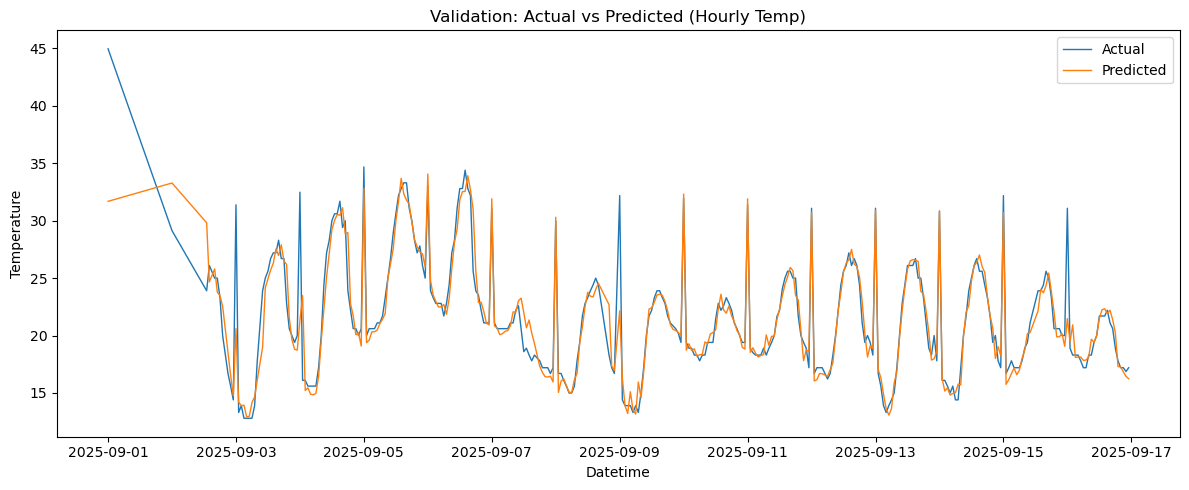

In [9]:
y_val_pred = best_model.predict(X_val)
rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
mae  = float(mean_absolute_error(y_val, y_val_pred))
r2   = float(r2_score(y_val, y_val_pred))

print(f"\nValidation (2025-09-01 → 2025-09-16):")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

plt.figure(figsize=(12,5))
plt.plot(val_df["ds"], y_val.values, label="Actual", linewidth=1)
plt.plot(val_df["ds"], y_val_pred, label="Predicted", linewidth=1)
plt.title("Validation: Actual vs Predicted (Hourly Temp)")
plt.xlabel("Datetime")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

<h2>Predictions</h2>

In [10]:
f_start = pd.Timestamp("2025-09-17 00:00:00")
f_end = pd.Timestamp("2025-09-30 23:59:59")

history = train_df.set_index("ds")[target].astype(float).copy()
history = pd.concat([history, val_df.set_index("ds")[target].astype(float)]).sort_index()

future_idx = pd.date_range(f_start, f_end, freq="h", inclusive="both")

def build_feature_row(ts, hist_series):
    row = {}
    
    row["year"]  = ts.year
    row["month"] = ts.month
    row["day"]   = ts.day
    row["hour"]  = ts.hour
    doy = ts.timetuple().tm_yday
    row["hour_sin"] = np.sin(2*np.pi*ts.hour/24.0)
    row["hour_cos"] = np.cos(2*np.pi*ts.hour/24.0)
    row["doy_sin"]  = np.sin(2*np.pi*doy/366.0)
    row["doy_cos"]  = np.cos(2*np.pi*doy/366.0)
    
    for L in lag_hours:
        lag_ts = ts - pd.Timedelta(hours=L)
        row[f"lag_{L}h"] = hist_series.get(lag_ts, np.nan)
    return row

future_rows = []
for ts in future_idx:
    feat_row = build_feature_row(ts, history)
    
    x = pd.DataFrame([feat_row], columns=features).astype(float)
    y_hat = best_model.predict(x)[0]
    future_rows.append({"ds": ts, "pred_hourlyDryBulbTemperature": y_hat})
    history.loc[ts] = y_hat

predictions = pd.DataFrame(future_rows).sort_values("ds").reset_index(drop=True)

print("\nForecast sample (first 10 rows):")
print(predictions.head(10))


Forecast sample (first 10 rows):
                   ds  pred_hourlyDryBulbTemperature
0 2025-09-17 00:00:00                      30.616672
1 2025-09-17 01:00:00                      15.997807
2 2025-09-17 02:00:00                      15.384353
3 2025-09-17 03:00:00                      15.088508
4 2025-09-17 04:00:00                      15.019741
5 2025-09-17 05:00:00                      15.129979
6 2025-09-17 06:00:00                      15.232011
7 2025-09-17 07:00:00                      16.464147
8 2025-09-17 08:00:00                      17.703785
9 2025-09-17 09:00:00                      19.068090


In [11]:
rf_est = best_model
imp = (
    pd.DataFrame({"feature": features, "importance": rf_est.feature_importances_})
    .sort_values("importance", ascending=False)
)
print("\nTop features By Importance:")
print(imp.head(12))

# Permutation importance on validation
perm = permutation_importance(best_model, X_val, y_val,n_repeats=10, random_state=0, n_jobs=-1)
perm_imp = (
    pd.DataFrame({
        "feature": features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)
print("\nTop Features By Permutation Importance (Validation):")
print(perm_imp.head(12))


Top features By Importance:
     feature  importance
8     lag_1h    0.593785
9     lag_2h    0.227162
10    lag_3h    0.088417
13   lag_24h    0.073741
5   hour_cos    0.004989
3       hour    0.003681
0       year    0.003400
14   lag_48h    0.001312
15   lag_72h    0.000932
7    doy_cos    0.000613
12   lag_12h    0.000435
4   hour_sin    0.000395

Top Features By Permutation Importance (Validation):
     feature  importance_mean  importance_std
8     lag_1h         0.755943        0.044343
9     lag_2h         0.165923        0.016948
3       hour         0.114044        0.006613
5   hour_cos         0.091361        0.010596
13   lag_24h         0.024292        0.025523
10    lag_3h         0.008173        0.005019
4   hour_sin         0.002824        0.000465
12   lag_12h         0.002435        0.000948
14   lag_48h         0.001402        0.001306
11    lag_6h         0.001007        0.000821
16  lag_168h         0.000729        0.000911
7    doy_cos         0.000020        0.0

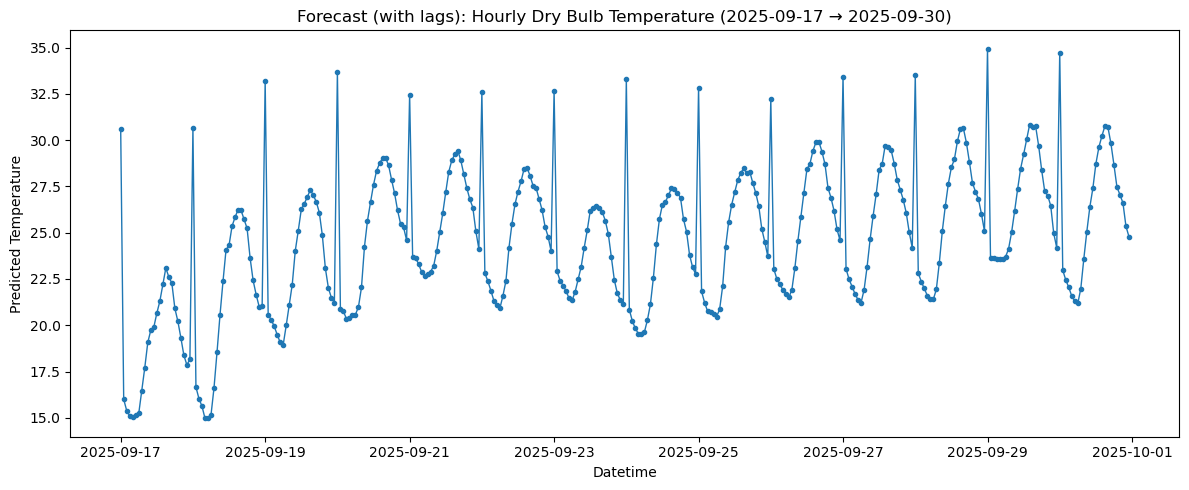

In [12]:
plt.figure(figsize=(12,5))
plt.plot(predictions["ds"], predictions["pred_hourlyDryBulbTemperature"], marker='.', linewidth=1)
plt.title("Forecast (with lags): Hourly Dry Bulb Temperature (2025-09-17 → 2025-09-30)")
plt.xlabel("Datetime")
plt.ylabel("Predicted Temperature")
plt.tight_layout()
plt.show()